# 02 — Dataset Generation & Inspection

Generate a reproducible dataset of sequences from a 3-state Markov chain
whose transition matrix is drawn from a symmetric Dirichlet distribution,
save it to disk, and inspect its statistical properties.


In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
import torch
from markov_chain import (
    sample_sequences,
    sample_transition_matrix,
    stationary_distribution,
)
from torch.utils.data import DataLoader, Dataset
from tqdm.auto import tqdm

%matplotlib inline
%config InlineBackend.figure_format = 'retina'

/Users/ashrafahmed/code/slt-deep/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## Generate sequences

In [5]:
# -- Papermill parameters -----------------------------------------------------
DATA_DIR = "../data"  # output directory (string for papermill)
N_SEQUENCES = 3_000
MAX_SEQ_LEN = 10
SEED = 1
N_STATES = 5
# Symmetric Dirichlet for symmetric regimes: pass np.full(N_STATES, c) for concentration c.
# For a targeted pi, pass c * pi_target.
ALPHA = np.full(N_STATES, 1.0)
PAD_ID = -1

In [6]:
# -- Post-papermill coercions -------------------------------------------------
DATA_DIR = Path(DATA_DIR)
DATA_DIR.mkdir(parents=True, exist_ok=True)
print("Data dir:", DATA_DIR.resolve())

Data dir: /Users/ashrafahmed/code/slt-deep/projects/markov-chain-learning/experiments/single-chain/data


In [7]:
Ts = sample_transition_matrix(n_states=N_STATES, alpha=ALPHA, n=1, rng=SEED)
Ts = Ts[np.newaxis]  # (S, S) -> (1, S, S)
info = {"n_chains": 1, "alpha_mode": "symmetric"}

N_CHAINS = Ts.shape[0]
pis = np.stack([stationary_distribution(Ts[k]) for k in range(N_CHAINS)], axis=0)
print(f"transition matrices: {np.round(Ts, 3)}")
print(f"limiting distributions: {pis}")

transition matrices: [[[0.148 0.043 0.743 0.051 0.016]
  [0.494 0.137 0.151 0.008 0.21 ]
  [0.264 0.058 0.425 0.053 0.199]
  [0.027 0.19  0.095 0.142 0.546]
  [0.138 0.112 0.353 0.252 0.145]]]
limiting distributions: [[0.21331805 0.08373991 0.4258267  0.09358993 0.18352541]]


In [8]:
# Sample sequences using the stationary distribution of the selected chain.

seqs_lengths = np.random.choice(np.arange(2, MAX_SEQ_LEN), N_SEQUENCES)
sequences_np = np.full((N_SEQUENCES, MAX_SEQ_LEN), PAD_ID, dtype=np.int64)

for i in tqdm(range(N_SEQUENCES), desc="Sampling sequences"):
    seq_len = seqs_lengths[i]
    x = sample_sequences(Ts[0], n=1, seq_len=seq_len, prior=pis[0], rng=SEED + i)
    sequences_np[i, : len(x[0])] = x[0]

sequences = torch.from_numpy(sequences_np).long()
# Single-chain experiment: every sequence is generated by chain 0.
chain_to_sample = np.zeros(N_SEQUENCES, dtype=np.int64)

print(f"sequences: {sequences.shape}  dtype={sequences.dtype}")
print("First 10 sequences:")
print(sequences[:10])
print(f"PAD count: {(sequences == PAD_ID).sum().item():,}")

Sampling sequences:  26%|██▌       | 768/3000 [00:00<00:00, 7672.95it/s]

Sampling sequences: 100%|██████████| 3000/3000 [00:00<00:00, 8673.41it/s]

sequences: torch.Size([3000, 10])  dtype=torch.int64
First 10 sequences:
tensor([[ 2,  4,  1,  4, -1, -1, -1, -1, -1, -1],
        [ 1,  0,  2,  0,  2,  2,  0,  0,  2, -1],
        [ 0,  2, -1, -1, -1, -1, -1, -1, -1, -1],
        [ 4,  2,  4,  0,  2,  2,  4, -1, -1, -1],
        [ 3,  4,  2,  1,  0, -1, -1, -1, -1, -1],
        [ 2,  2,  2,  2, -1, -1, -1, -1, -1, -1],
        [ 2,  4, -1, -1, -1, -1, -1, -1, -1, -1],
        [ 2,  4,  2,  3,  4,  2,  2,  2,  0, -1],
        [ 4,  2,  2,  3,  4,  4,  4,  4, -1, -1],
        [ 4,  1,  4,  1,  1,  0,  2, -1, -1, -1]])
PAD count: 13,219


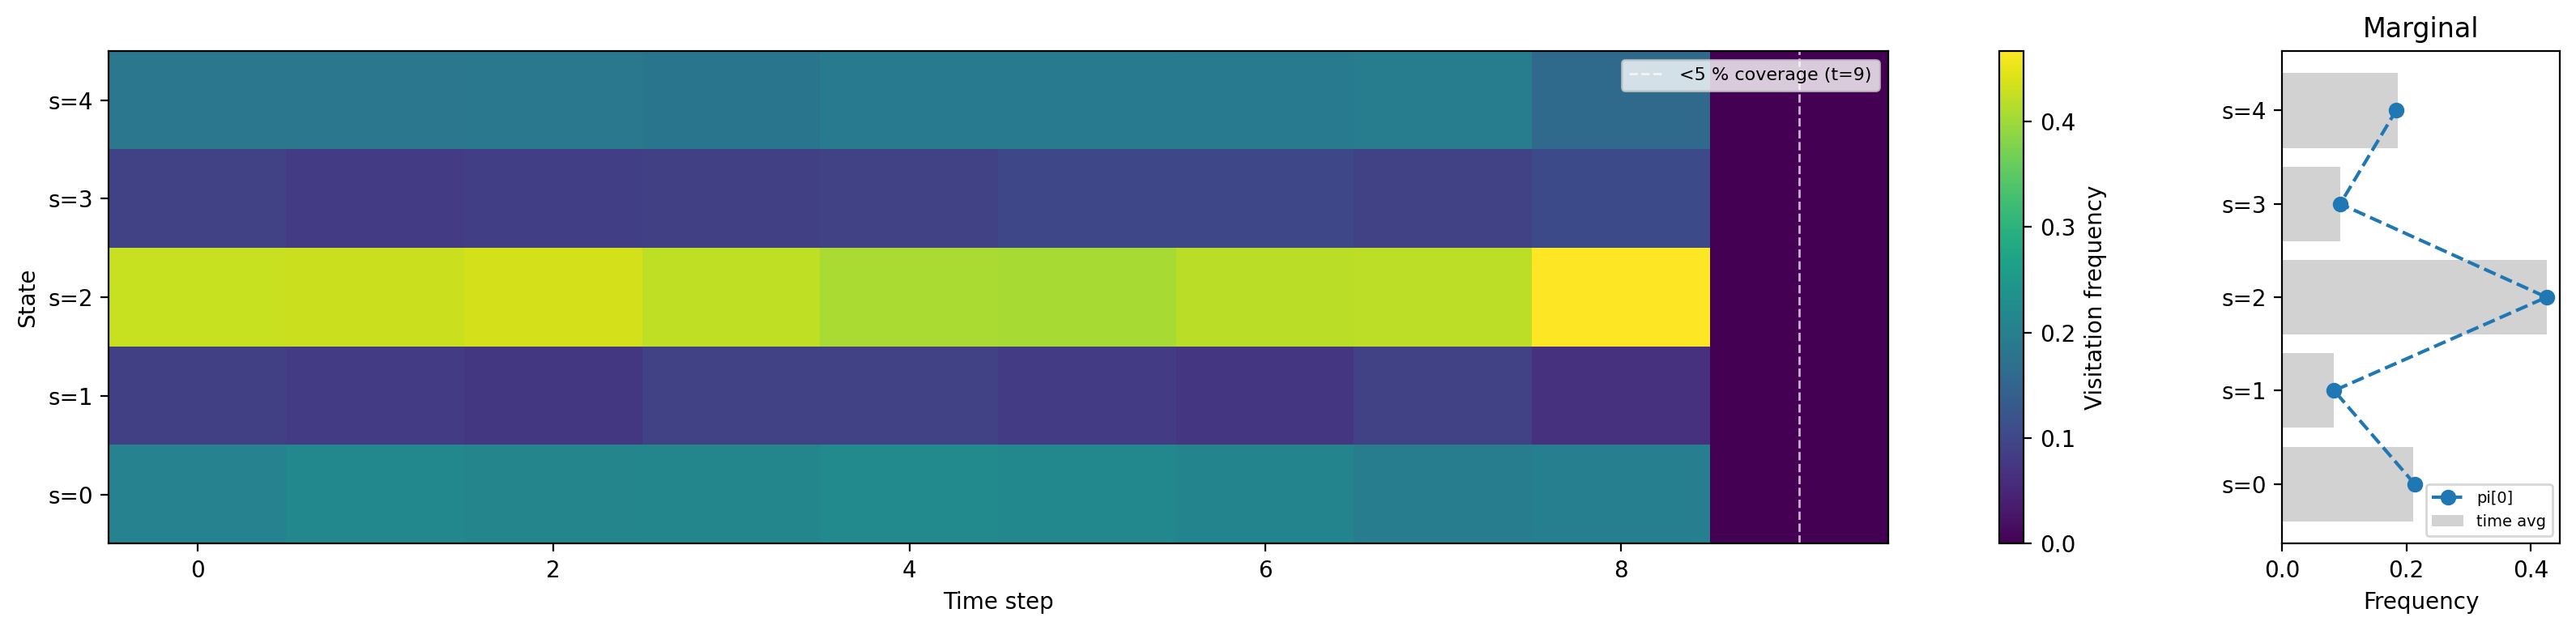

In [9]:
# State visitation frequency heatmap: rows = states, cols = time steps.
# For each time step t we count how many (non-PAD) sequences visit each state,
# then normalise so columns sum to 1. The expected pattern is that the
# empirical marginal at every t converges to a mixture of the stationary
# distributions (one per chain), not to any single one.

seqs_np = sequences.numpy()  # (N, L)
_, L = seqs_np.shape

freq = np.zeros((N_STATES, L), dtype=float)
n_valid_per_t = np.zeros(L, dtype=int)
for t in range(L):
    col = seqs_np[:, t]
    valid = col != PAD_ID
    n = int(valid.sum())
    n_valid_per_t[t] = n
    if n > 0:
        freq[:, t] = np.bincount(col[valid], minlength=N_STATES) / n

# Keep plots readable when N_STATES is large.
MAX_Y_TICKS = 20
TARGET_ROW_HEIGHT = 0.18
MIN_FIG_HEIGHT = 4.0
MAX_FIG_HEIGHT = 9.0

fig_height = float(
    np.clip(2.0 + N_STATES * TARGET_ROW_HEIGHT, MIN_FIG_HEIGHT, MAX_FIG_HEIGHT)
)
tick_step = max(1, int(np.ceil(N_STATES / MAX_Y_TICKS)))
yticks = np.arange(0, N_STATES, tick_step, dtype=int)
if len(yticks) == 0 or yticks[-1] != N_STATES - 1:
    yticks = np.append(yticks, N_STATES - 1)
ylabels = [f"s={s}" for s in yticks]

fig, axes = plt.subplots(
    1,
    2,
    figsize=(16, fig_height),
    gridspec_kw={"width_ratios": [8, 1]},
)

# Main heatmap
ax = axes[0]
im = ax.imshow(
    freq,
    aspect="auto",
    origin="lower",
    cmap="viridis",
    extent=[-0.5, L - 0.5, -0.5, N_STATES - 0.5],
    vmin=0,
    vmax=freq.max(),
)
fig.colorbar(im, ax=ax, label="Visitation frequency")
ax.set_xlabel("Time step")
ax.set_ylabel("State")
ax.set_yticks(yticks)
ax.set_yticklabels(ylabels)

# Mark where sequence coverage drops to <5 % of the dataset
cutoff = np.searchsorted(-n_valid_per_t, -int(0.05 * len(sequences)))
if cutoff < L:
    ax.axvline(
        cutoff,
        color="white",
        linestyle="--",
        linewidth=1,
        alpha=0.7,
        label=f"<5 % coverage (t={cutoff})",
    )
    ax.legend(fontsize=8, loc="upper right")

# Right panel: marginal (time-avg) vs stationary dists
ax2 = axes[1]
active = n_valid_per_t > 0
time_avg = freq[:, active].mean(axis=1)

ax2.barh(range(N_STATES), time_avg, color="gray", alpha=0.35, label="time avg")
prop_cycle = plt.rcParams["axes.prop_cycle"].by_key()["color"]
for k in range(N_CHAINS):
    ax2.plot(
        pis[k],
        range(N_STATES),
        "o--",
        color=prop_cycle[k],
        linewidth=1.5,
        label=f"pi[{k}]",
    )

if N_CHAINS > 1:
    mixture = pis.mean(axis=0)
    ax2.plot(
        mixture, range(N_STATES), "s:", color="black", linewidth=1.5, label="avg(pi)"
    )

ax2.set_xlabel("Frequency")
ax2.set_title("Marginal")
ax2.set_yticks(yticks)
ax2.set_yticklabels(ylabels)
ax2.legend(fontsize=7, loc="lower right")

plt.tight_layout()
plt.show()

## Save to disk


In [10]:
save_path = DATA_DIR / "sequences.pt"

# Keep cell self-contained for notebook linting.
chain_to_sample_arr = np.zeros(N_SEQUENCES, dtype=np.int64)
dgp_regime = "single"

torch.save(
    {
        "sequences": sequences,
        "Ts": torch.tensor(Ts, dtype=torch.float32),
        "pis": torch.tensor(pis, dtype=torch.float32),
        "chain_to_sample": torch.tensor(chain_to_sample_arr, dtype=torch.long),
        "seq_lengths": torch.tensor(seqs_lengths, dtype=torch.long),
        "config": {
            "N": N_SEQUENCES,
            "L": MAX_SEQ_LEN,
            "seed": SEED,
            "n_chains": N_CHAINS,
            "n_states": N_STATES,
            "alpha": ALPHA,
            "pad_id": PAD_ID,
            "dgp_regime": dgp_regime,
        },
    },
    save_path,
)
print(f"Saved -> {save_path}  ({save_path.stat().st_size / 1024:.1f} KB)")

Saved -> ../data/sequences.pt  (284.3 KB)


Per-chain empirical start probs vs stationary pi:
  chain 0: emp=[0.206 0.089 0.427 0.092 0.185]  pi=[0.213 0.084 0.426 0.094 0.184]

Overall empirical start probs: [0.206 0.089 0.427 0.092 0.185]
Overall expected (mixture):  [0.213 0.084 0.426 0.094 0.184]


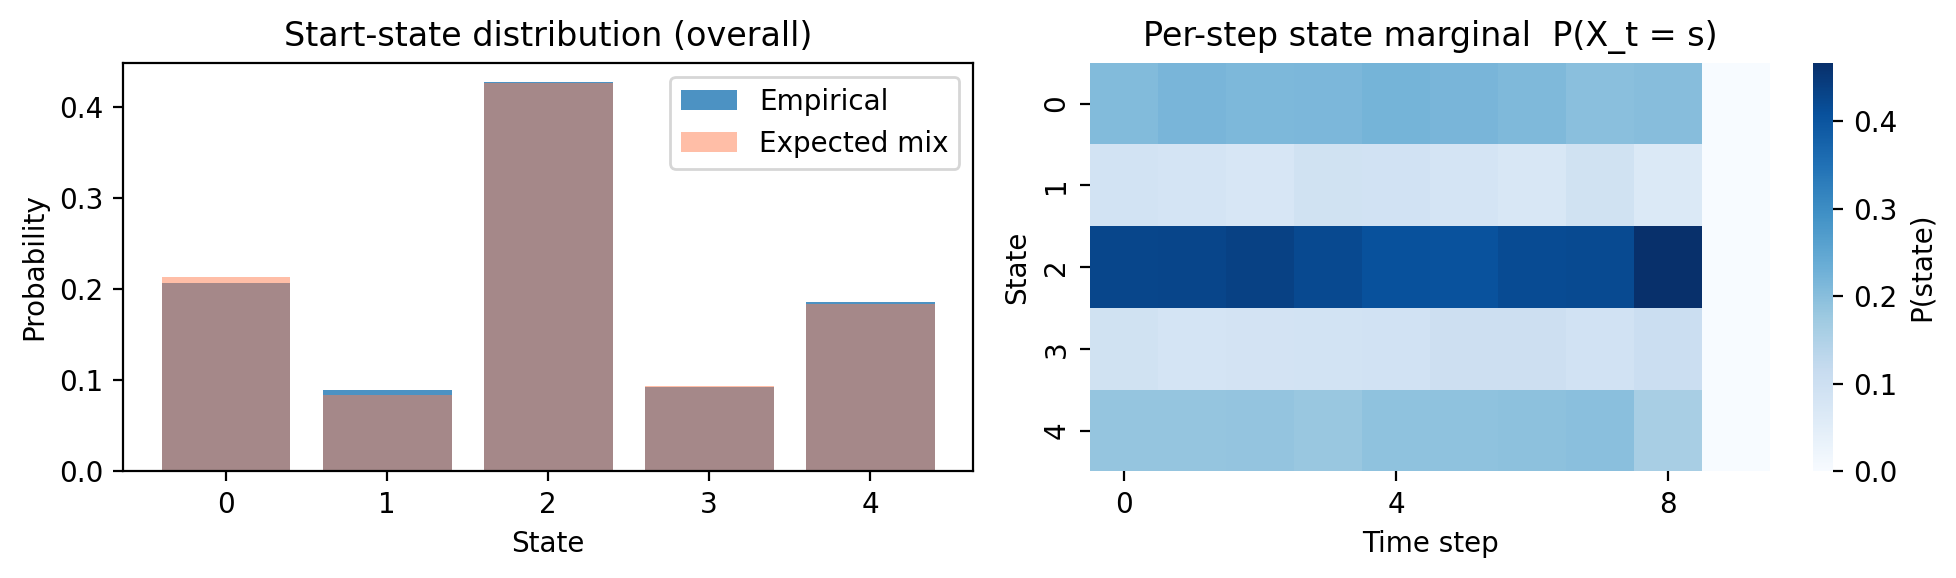

In [11]:
# Start-state verification against multiple stationary distributions.
start_tokens = sequences[:, 0]
valid_start = start_tokens != PAD_ID

chain_to_sample_arr = np.zeros(N_SEQUENCES, dtype=np.int64)
chain_ids = torch.from_numpy(chain_to_sample_arr).long()
emp_pi_by_chain = np.zeros((N_CHAINS, N_STATES), dtype=float)

for k in range(N_CHAINS):
    mask_k = valid_start & (chain_ids == k)
    if mask_k.any():
        counts_k = torch.bincount(start_tokens[mask_k], minlength=N_STATES).float()
        emp_pi_by_chain[k] = (counts_k / counts_k.sum()).numpy()

print("Per-chain empirical start probs vs stationary pi:")
for k in range(N_CHAINS):
    print(
        f"  chain {k}: emp={np.round(emp_pi_by_chain[k], 3)}  pi={np.round(pis[k], 3)}"
    )

# Aggregate expected start distribution is a mixture of chain-specific pi's.
chain_weights = np.bincount(chain_to_sample_arr, minlength=N_CHAINS).astype(float)
chain_weights /= chain_weights.sum()
pi_mix = chain_weights @ pis

start_counts = torch.bincount(start_tokens[valid_start], minlength=N_STATES).float()
emp_mix = (start_counts / start_counts.sum()).numpy()

print("\nOverall empirical start probs:", np.round(emp_mix, 3))
print("Overall expected (mixture): ", np.round(pi_mix, 3))

fig, axes = plt.subplots(1, 2, figsize=(10, 3))

# Bar chart: overall empirical start-state vs expected mixture.
axes[0].bar(range(N_STATES), emp_mix, label="Empirical", alpha=0.8)
axes[0].bar(range(N_STATES), pi_mix, alpha=0.5, label="Expected mix", color="coral")
axes[0].set_xlabel("State")
axes[0].set_ylabel("Probability")
axes[0].set_title("Start-state distribution (overall)")
axes[0].legend()

# Per-step state marginals (heatmap: state x time), ignoring PAD_ID tokens.
marginals = torch.zeros(N_STATES, MAX_SEQ_LEN)
for t in range(MAX_SEQ_LEN):
    token_t = sequences[:, t]
    valid_t = token_t != PAD_ID
    if valid_t.any():
        counts = torch.bincount(token_t[valid_t], minlength=N_STATES).float()
        marginals[:, t] = counts / counts.sum()

sns.heatmap(
    marginals.numpy(),
    ax=axes[1],
    cmap="Blues",
    xticklabels=4,
    yticklabels=range(N_STATES),
    cbar_kws={"label": "P(state)"},
)
axes[1].set_xlabel("Time step")
axes[1].set_ylabel("State")
axes[1].set_title("Per-step state marginal  P(X_t = s)")

plt.tight_layout()
plt.show()

## Dataset & DataLoader


In [12]:
class MarkovSequenceDataset(Dataset):
    """Wraps a (N, L) LongTensor of Markov chain sequences."""

    def __init__(self, sequences: torch.Tensor):
        self.data = sequences

    def __len__(self) -> int:
        return len(self.data)

    def __getitem__(self, idx: int) -> torch.Tensor:
        return self.data[idx]


dataset = MarkovSequenceDataset(sequences)
loader = DataLoader(dataset, batch_size=256, shuffle=True)

# Sanity check: one batch
batch = next(iter(loader))
print(f"One batch: {batch.shape}  dtype={batch.dtype}")

One batch: torch.Size([256, 10])  dtype=torch.int64
